
# 1.0 Groceries dataset cleaning and analysis

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from itertools import combinations
from collections import Counter
from statsmodels.tsa.stattools import acf, pacf

# ==========================================
# 0. Data Loading & Preprocessing
# ==========================================
def load_data(filepath='groceries_dataset.csv'):
    """Loads and preprocesses the grocery dataset."""
    df = pd.read_csv(filepath)
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df = df.dropna(subset=['Date'])
    df = df.sort_values(by='Date')
    
    df['DayOfWeek'] = df['Date'].dt.day_name()
    df['Month'] = df['Date'].dt.month_name()
    return df

def get_category_counts(df):
    """Helper to get total purchase counts per product."""
    cat_counts = df['itemDescription'].value_counts().reset_index()
    cat_counts.columns = ['Product', 'Total Purchases']
    return cat_counts
def get_frequent_pairs(df, top_n=20):
    """
    Market Basket Analysis with proper metrics:
    - count
    - support
    - confidence
    - lift
    """

    # Create baskets
    baskets = df.groupby(['Member_number', 'Date'])['itemDescription'] \
                .apply(lambda x: list(set(x)))

    total_transactions = len(baskets)

    # Count individual items
    item_counts = Counter()
    for basket in baskets:
        item_counts.update(basket)

    # Count pairs
    pair_counts = Counter()
    for basket in baskets:
        if len(basket) > 1:
            for pair in combinations(sorted(basket), 2):
                pair_counts[pair] += 1

    results = []

    for (A, B), count_xy in pair_counts.items():
        count_x = item_counts[A]
        count_y = item_counts[B]

        # --- METRICS ---
        support_xy = count_xy / total_transactions
        support_x = count_x / total_transactions
        support_y = count_y / total_transactions

        confidence = count_xy / count_x
        lift = support_xy / (support_x * support_y)

        results.append({
            "Pair": f"{A} + {B}",
            "Frequency": count_xy,
            "Support": support_xy,
            "Confidence": confidence,
            "Lift": lift
        })

    pairs_df = pd.DataFrame(results)

    return pairs_df.sort_values(by='Lift', ascending=False).head(top_n)
# ==========================================
# 1. Total Count Table
# ==========================================
def plot_popularity_table(df):
    cat_counts = get_category_counts(df)
    total_all_purchases = cat_counts['Total Purchases'].sum()
    cat_counts['Percentage'] = (cat_counts['Total Purchases'] / total_all_purchases * 100).round(2).astype(str) + '%'
    
    sample_df = cat_counts.head(50)
    fig = go.Figure(data=[go.Table(
        header=dict(values=['Rank', 'Product', 'Total Purchases', '% of Entire Catalog'], fill_color='paleturquoise', align='left'),
        cells=dict(values=[list(range(1, 51)), sample_df['Product'], sample_df['Total Purchases'], sample_df['Percentage']], fill_color='lavender', align='left'))
    ])
    fig.update_layout(title="1. Product Popularity Table (Top 50 Items)", height=400, margin=dict(t=50, b=0))
    return fig

# ==========================================
# 2. Treemap of ALL Categories
# ==========================================
def plot_treemap(df):
    cat_counts = get_category_counts(df)
    
    fig = px.treemap(
        cat_counts, 
        path=[px.Constant("All Products"), 'Product'], 
        values='Total Purchases',
        color='Total Purchases',
        color_continuous_scale='Blues',
        title="2. Total Catalog Distribution (Treemap)"
    )
    
    # Customizing Traces to show EXACTLY % on cells, and both count + % on hover
    fig.update_traces(
        textinfo="label+percent root",
        hovertemplate="<b>%{label}</b><br>Total Purchases: %{value}<br>Share: %{percentRoot:.2%}<extra></extra>"
    )
    fig.update_layout(height=600, margin=dict(t=50, l=10, r=10, b=10))
    return fig

# ==========================================
# 3. Bar Chart of Popular Products
# ==========================================
def plot_top_products_bar(df):
    cat_counts = get_category_counts(df)
    top_25 = cat_counts.head(25)
    fig = px.bar(
        top_25, x='Product', y='Total Purchases', 
        color='Total Purchases', color_continuous_scale='Plasma',
        title="3. Most Popular Products (Top 25)"
    )
    fig.update_xaxes(tickangle=-45)
    fig.update_layout(height=500)
    return fig

# ==========================================
# 4. Time Series Trend (Weekly)
# ==========================================
def plot_time_series(df):
    weekly_demand = df.groupby(pd.Grouper(key='Date', freq='W')).size().reset_index(name='Demand')
    
    full_idx = pd.date_range(weekly_demand['Date'].min(), weekly_demand['Date'].max(), freq='W')
    weekly_demand = weekly_demand.set_index('Date').reindex(full_idx, fill_value=0).reset_index()
    weekly_demand.rename(columns={'index': 'Date'}, inplace=True)
    weekly_demand = weekly_demand.dropna()
    
    fig = px.line(
        weekly_demand, x='Date', y='Demand', markers=True,
        title="4. Chronological Demand Over Time (Aggregated WEEKLY for clarity)"
    )
    fig.update_traces(line=dict(width=3, color='royalblue'), marker=dict(size=6, color='darkblue'))
    fig.update_layout(xaxis_title="Date (Weeks)", yaxis_title="Total Weekly Items Purchased", height=500)
    return fig

# ==========================================
# 5. Seasonality Heatmap
# ==========================================
def plot_seasonality_heatmap(df):
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

    daily_demand = df.groupby('Date').size().reset_index(name='Demand')
    daily_demand['DayOfWeek'] = daily_demand['Date'].dt.day_name()
    daily_demand['Month'] = daily_demand['Date'].dt.month_name()
    
    heatmap_pivot = daily_demand.groupby(['DayOfWeek', 'Month'])['Demand'].mean().unstack(fill_value=0)
    heatmap_pivot = heatmap_pivot.reindex(index=days_order, columns=months_order, fill_value=0)
    
    if heatmap_pivot.empty or heatmap_pivot.values.sum() == 0:
        print("WARNING: Heatmap matrix is completely empty.")
        return go.Figure()

    fig = go.Figure(data=go.Heatmap(
        z=heatmap_pivot.values,
        x=heatmap_pivot.columns,
        y=heatmap_pivot.index,
        colorscale='Viridis',
        texttemplate="%{z:.1f}",
        textfont={"size": 11}
    ))
    fig.update_layout(title="5. Advanced Insight: Average Daily Demand (Day vs Month)", height=500)
    return fig

# ==========================================
# 6. Advanced: ACF & PACF
# ==========================================
def plot_acf_pacf(df):
    # =========================
    # DAILY → base aggregation
    # =========================
    daily = df.groupby('Date').size().reset_index(name='Demand')
    full_daily_idx = pd.date_range(daily['Date'].min(), daily['Date'].max())
    daily_series = daily.set_index('Date').reindex(full_daily_idx, fill_value=0)['Demand']

    # =========================
    # WEEKLY aggregation
    # =========================
    weekly = daily_series.resample('W').sum()

    # =========================
    # MONTHLY aggregation
    # =========================
    monthly = daily_series.resample('ME').sum()

    # =========================
    # ACF / PACF calculations
    # =========================
    acf_weekly = acf(weekly, nlags=20)
    pacf_weekly = pacf(weekly, nlags=20)

    acf_monthly = acf(monthly, nlags=12)
    pacf_monthly = pacf(monthly, nlags=12)

    # =========================
    # PLOT GRID (2x2)
    # =========================
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Weekly ACF", "Weekly PACF",
            "Monthly ACF", "Monthly PACF"
        )
    )

    # --- Weekly ACF ---
    fig.add_trace(
        go.Bar(x=np.arange(len(acf_weekly)), y=acf_weekly, marker_color='darkblue'),
        row=1, col=1
    )

    # --- Weekly PACF ---
    fig.add_trace(
        go.Bar(x=np.arange(len(pacf_weekly)), y=pacf_weekly, marker_color='darkred'),
        row=1, col=2
    )

    # --- Monthly ACF ---
    fig.add_trace(
        go.Bar(x=np.arange(len(acf_monthly)), y=acf_monthly, marker_color='blue'),
        row=2, col=1
    )

    # --- Monthly PACF ---
    fig.add_trace(
        go.Bar(x=np.arange(len(pacf_monthly)), y=pacf_monthly, marker_color='red'),
        row=2, col=2
    )

    # =========================
    # Confidence bounds
    # =========================
    conf = 0.05
    for r in [1, 2]:
        for c in [1, 2]:
            fig.add_hline(y=conf, line_dash="dash", line_color="black", row=r, col=c)
            fig.add_hline(y=-conf, line_dash="dash", line_color="black", row=r, col=c)

    # =========================
    # AXIS LABELS (THIS IS THE FIX)
    # =========================
    fig.update_xaxes(title_text="Lag", row=1, col=1)
    fig.update_xaxes(title_text="Lag", row=1, col=2)
    fig.update_xaxes(title_text="Lag", row=2, col=1)
    fig.update_xaxes(title_text="Lag", row=2, col=2)

    fig.update_yaxes(title_text="Correlation", row=1, col=1)
    fig.update_yaxes(title_text="Correlation", row=1, col=2)
    fig.update_yaxes(title_text="Correlation", row=2, col=1)
    fig.update_yaxes(title_text="Correlation", row=2, col=2)

    # =========================
    # Layout
    # =========================
    fig.update_layout(
        title="6. Advanced Insight: ACF & PACF (Weekly vs Monthly)",
        height=700,
        showlegend=False
    )

    return fig

# ==========================================
# 7. Frequently Bought Together (Basket)
# ==========================================
def plot_market_basket(df, top_n=20, max_per_item=3):
    """
    FINAL version with dominance control.

    Fixes:
    - milk dominating results
    - enforces diversity
    """

    baskets = df.groupby(['Member_number', 'Date'])['itemDescription'] \
        .apply(lambda x: list(set(x)))

    total_baskets = len(baskets)

    item_counts = Counter()
    pair_counts = Counter()

    for basket in baskets:
        item_counts.update(basket)
        if len(basket) > 1:
            for pair in combinations(sorted(basket), 2):
                pair_counts[pair] += 1

    results = []

    for (A, B), pair_count in pair_counts.items():
        support = pair_count / total_baskets
        confidence_A_B = pair_count / item_counts[A]
        confidence_B_A = pair_count / item_counts[B]

        lift = support / (
            (item_counts[A] / total_baskets) *
            (item_counts[B] / total_baskets)
        )

        confidence = max(confidence_A_B, confidence_B_A)

        # stronger penalty (IMPORTANT CHANGE)
        pop_penalty = (item_counts[A] + item_counts[B]) ** 0.75

        score = (support * confidence) / pop_penalty

        results.append({
            'Pair': f"{A} + {B}",
            'A': A,
            'B': B,
            'Frequency': pair_count,
            'Support': support,
            'Confidence': confidence,
            'Lift': lift,
            'Score': score
        })

    df_pairs = pd.DataFrame(results)

    # light filtering
    df_pairs = df_pairs[
        (df_pairs['Support'] > 0.001) &
        (df_pairs['Confidence'] > 0.05)
    ]

    # sort by score first
    df_pairs = df_pairs.sort_values(by='Score', ascending=False)

    # diversity constraint
    selected = []
    item_usage = Counter()

    for _, row in df_pairs.iterrows():
        if (
            item_usage[row['A']] < max_per_item and
            item_usage[row['B']] < max_per_item
        ):
            selected.append(row)
            item_usage[row['A']] += 1
            item_usage[row['B']] += 1

        if len(selected) >= top_n:
            break

    results_df = pd.DataFrame(selected)

    # Plot
    fig = px.bar(
        results_df.sort_values(by='Frequency'),
        x='Frequency',
        y='Pair',
        orientation='h',
        color='Lift',
        color_continuous_scale='Reds',
        text='Frequency',
        title="7. Market Basket Insight (Diversity-Controlled)"
    )

    fig.update_traces(
        hovertemplate=(
            "<b>%{y}</b><br>" +
            "Frequency: %{x}<br>" +
            "Support: %{customdata[0]:.4f}<br>" +
            "Confidence: %{customdata[1]:.4f}<br>" +
            "Lift: %{marker.color:.2f}<extra></extra>"
        ),
        customdata=results_df[['Support', 'Confidence']].values
    )

    fig.update_layout(height=600, margin=dict(l=150))

    return fig


Loading data...
1. Generating Table...


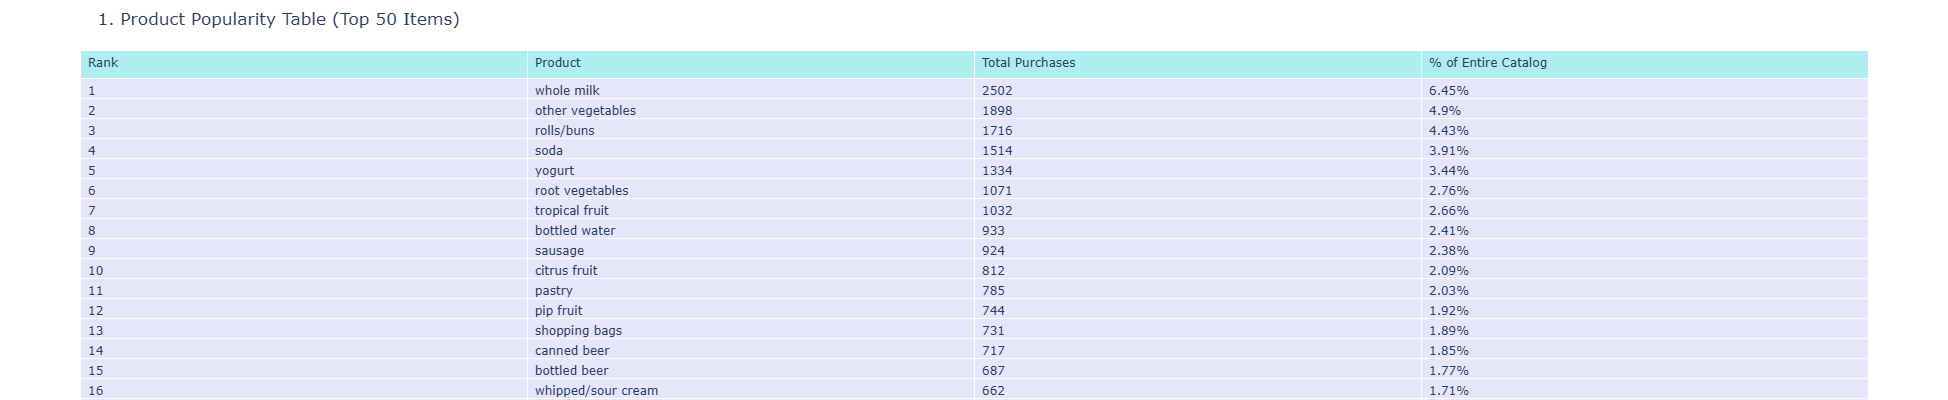

In [2]:

print("Loading data...")
df = load_data()

print("1. Generating Table...")
fig1 = plot_popularity_table(df)
fig1.show()


2. Generating Treemap...


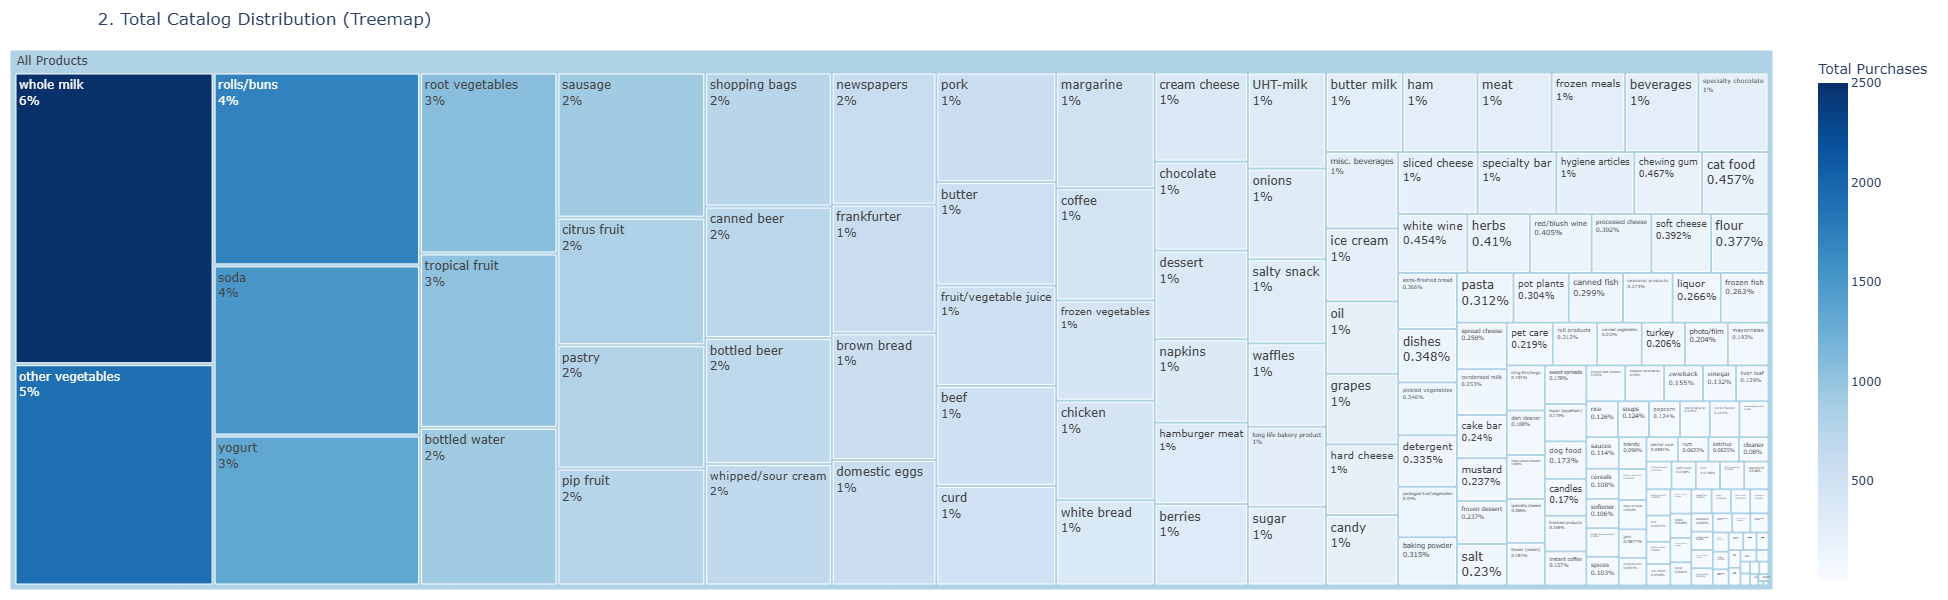

In [3]:

print("2. Generating Treemap...")
fig2 = plot_treemap(df)
fig2.show()


3. Generating Top Products Bar Chart...


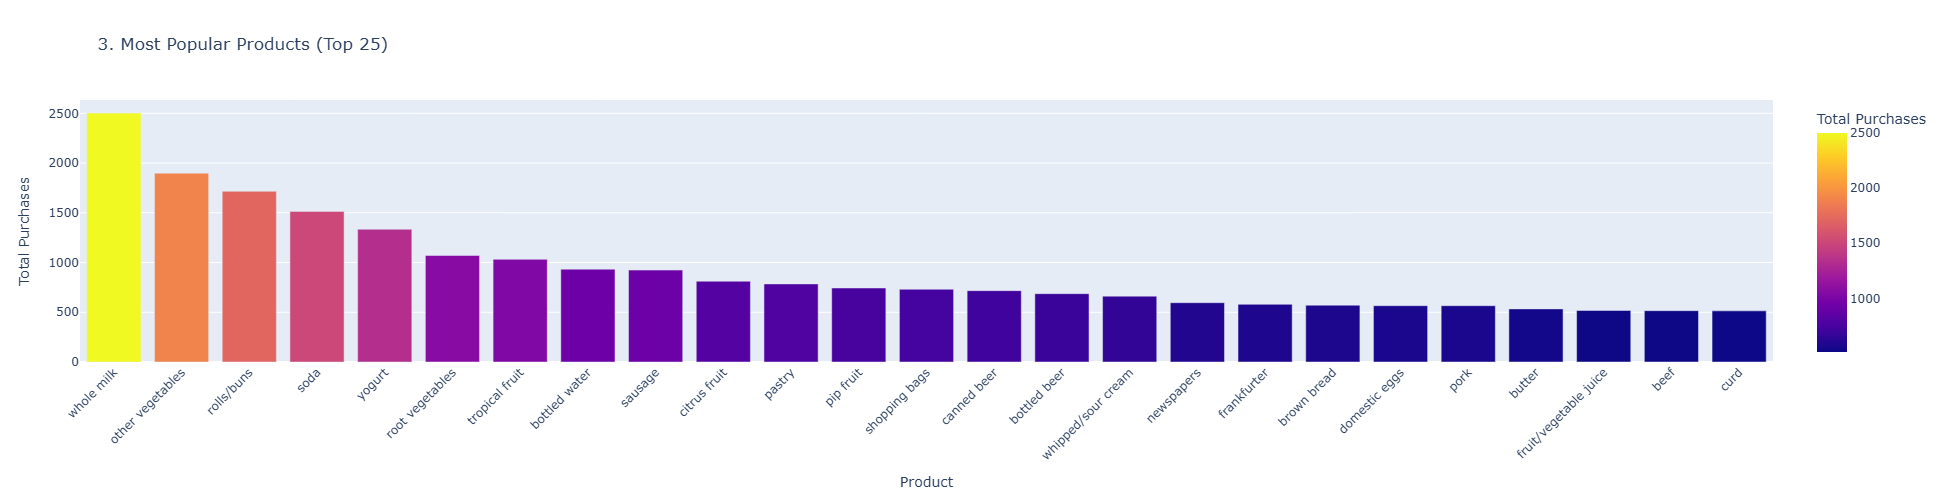

In [4]:

print("3. Generating Top Products Bar Chart...")
fig3 = plot_top_products_bar(df)
fig3.show()


4. Generating Time Series...


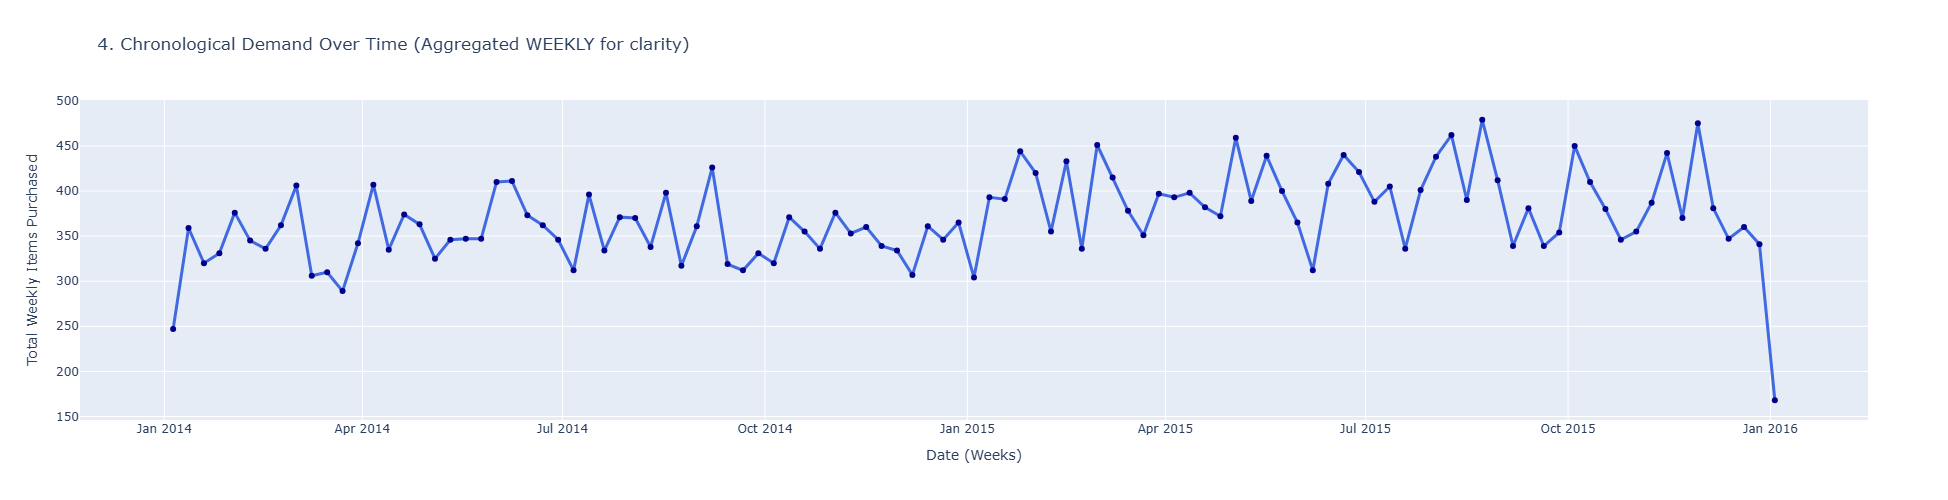

In [5]:

print("4. Generating Time Series...")
fig4 = plot_time_series(df)
fig4.show()


5. Generating Seasonality Heatmap...


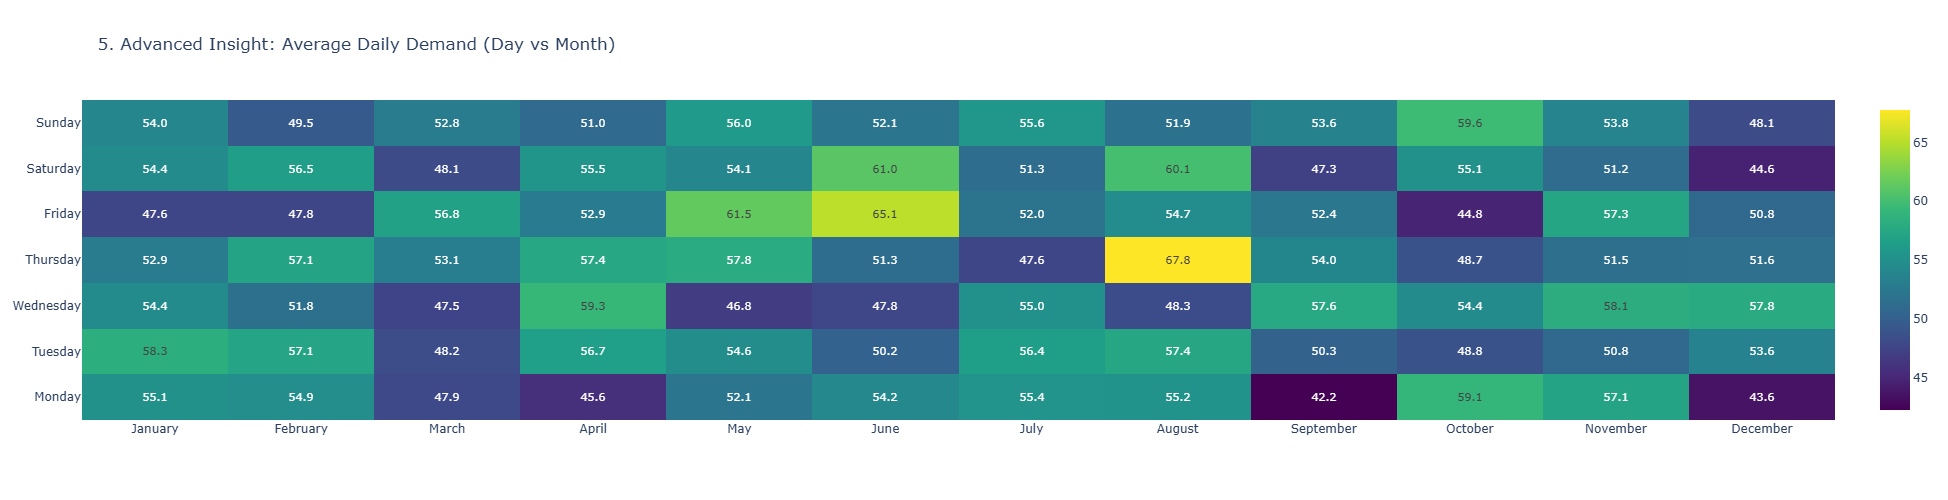

In [6]:

print("5. Generating Seasonality Heatmap...")
fig5 = plot_seasonality_heatmap(df)
fig5.show()


6. Generating ACF/PACF...


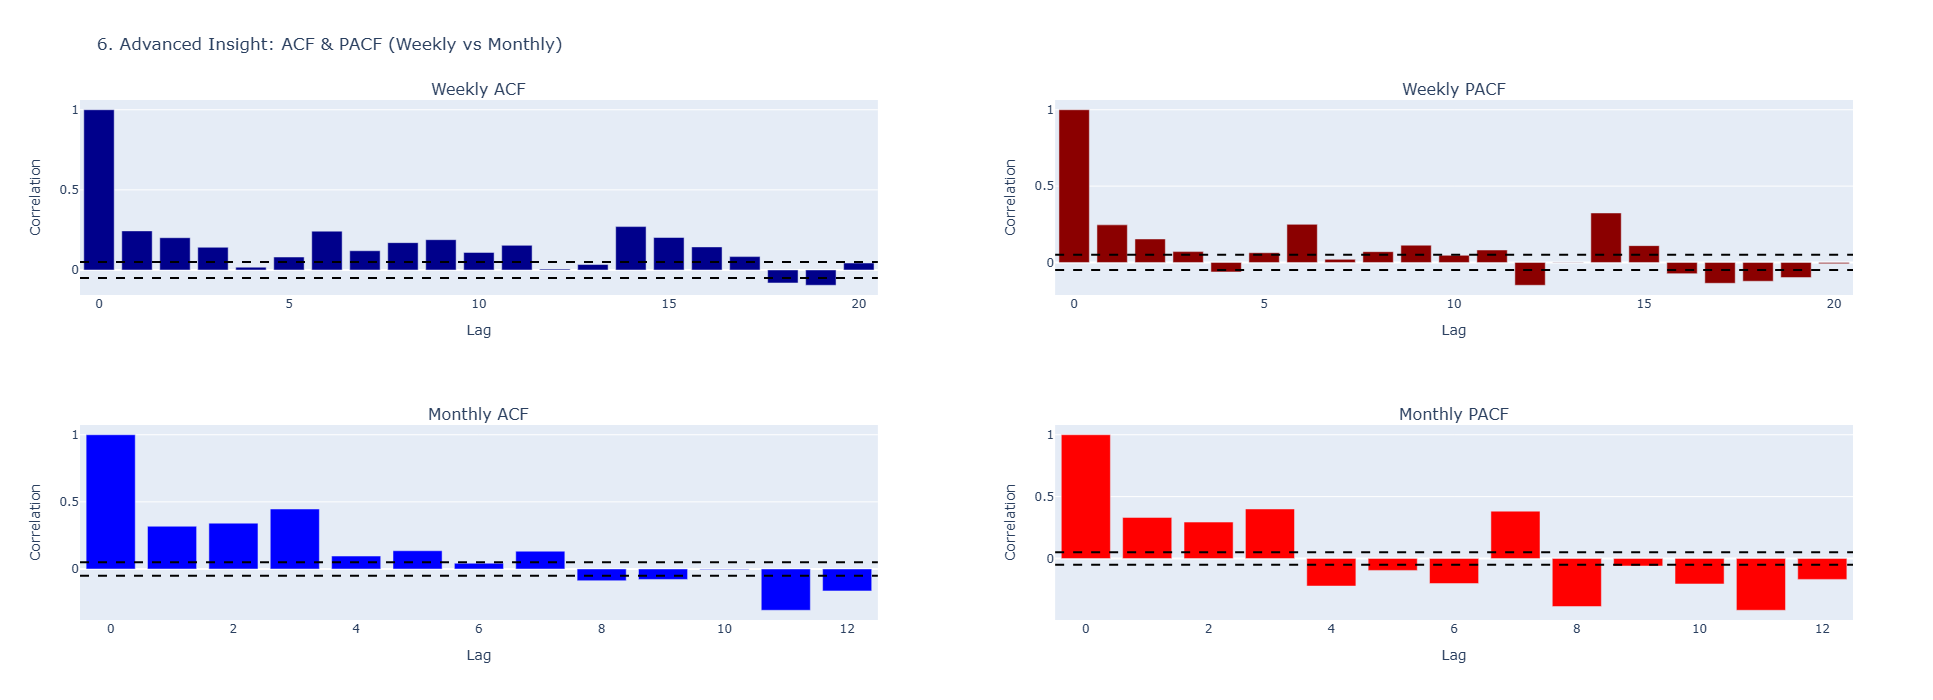

In [31]:

print("6. Generating ACF/PACF...")
fig6 = plot_acf_pacf(df)
fig6.show()



7. Generating Market Basket Pairs...


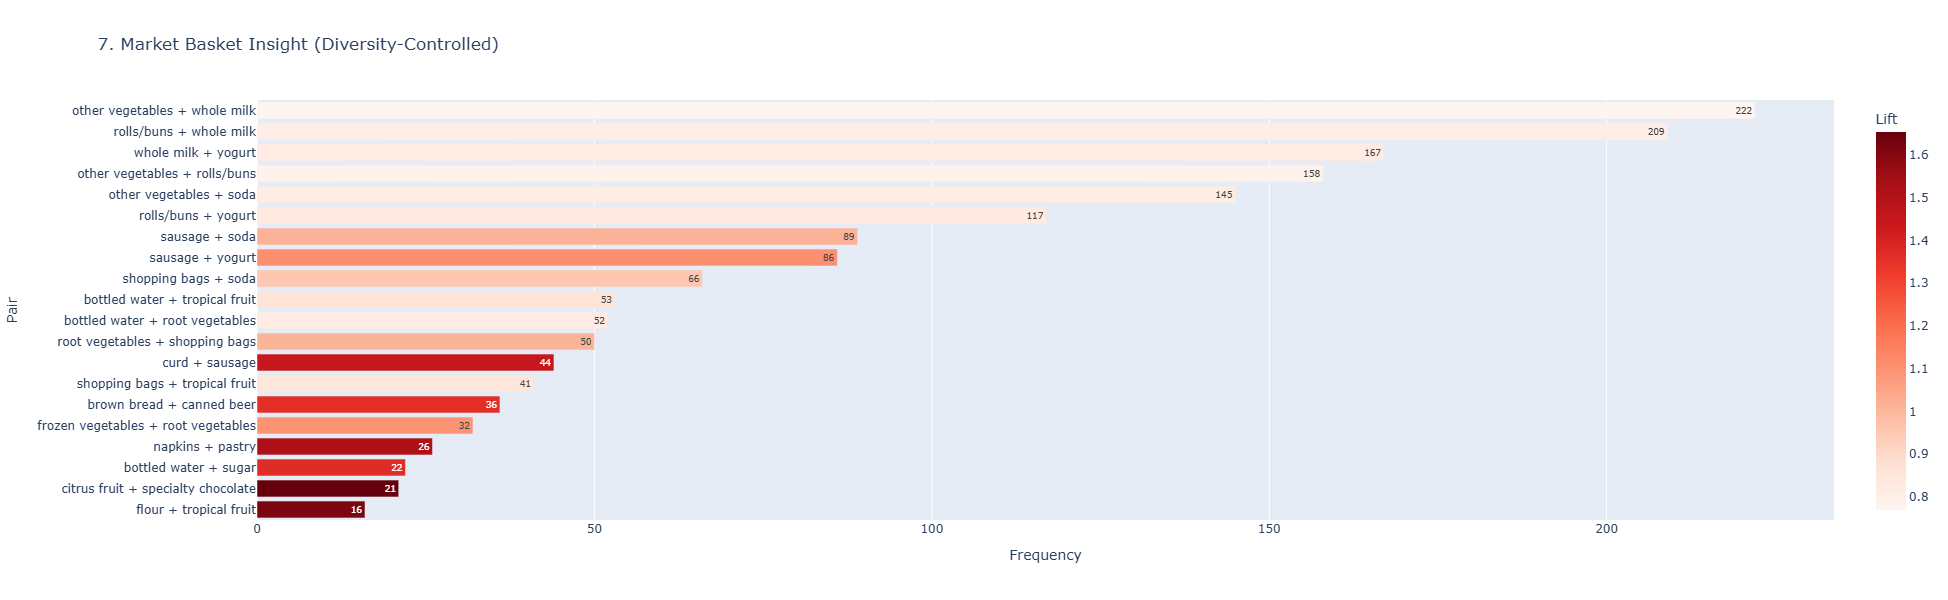

In [32]:

print("7. Generating Market Basket Pairs...")
fig7 = plot_market_basket(df)
fig7.show()
